<a href="https://colab.research.google.com/github/Zunairah-Kar/Fine-Tuning-MedGemma/blob/Collab/Fine_Tuning_MedGemma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -U transformers datasets evaluate peft trl accelerate \
    bitsandbytes scikit-learn kaggle huggingface_hub torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 141.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Succ

In [ ]:
import torch
from getpass import getpass
from huggingface_hub import login
from huggingface_hub import model_info
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
import os
import shutil
from datasets import load_dataset
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

In [ ]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("BF16 supported:", torch.cuda.is_bf16_supported())
else:
    raise RuntimeError("An NVIDIA CUDA GPU is required for this notebook.")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
BF16 supported: True


In [ ]:
hf_token = getpass("Enter your Hugging Face token: ")
login(token=hf_token)

model_info("google/medgemma-4b-it")
print("MedGemma access confirmed.")

In [ ]:
os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass("Kaggle API token: ")

!kaggle datasets download \
    -d orvile/brain-cancer-mri-dataset \
    --unzip \
    -p ./brain_mri_data

Resolving data files:   0%|          | 0/6056 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

['brain_glioma', 'brain_menin', 'brain_tumor']


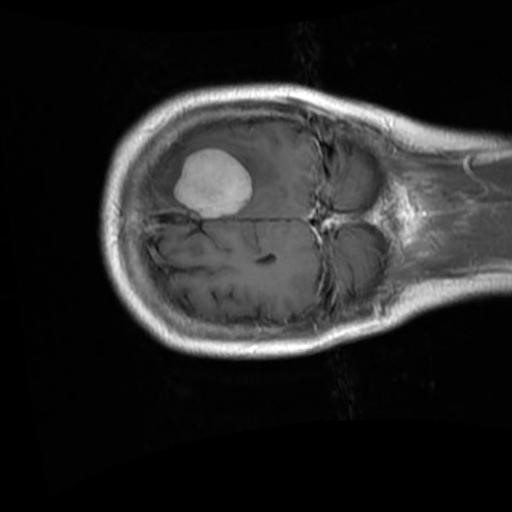

Label: 1


In [ ]:
data_dir = "./brain_mri_data/Brain_Cancer raw MRI data/Brain_Cancer"

dataset = load_dataset(
    "imagefolder",
    data_dir=data_dir,
    split="train",
)

dataset = dataset.train_test_split(
    train_size=0.8,
    test_size=0.2,
    shuffle=True,
    seed=42,
)

dataset["validation"] = dataset.pop("test")

print(dataset["train"].features["label"].names)
display(dataset["train"][0]["image"])
print("Label:", dataset["train"][0]["label"])

In [ ]:
CLASSES = [
    "A: brain glioma",
    "B: brain meningioma",
    "C: brain tumor",
]

PROMPT = (
    "What is the most likely type of brain cancer shown in the MRI image?\n"
    + "\n".join(CLASSES)
)

def format_example(example):
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": PROMPT},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": CLASSES[example["label"]]},
            ],
        },
    ]
    return example

formatted_dataset = dataset.map(format_example)
formatted_dataset["train"][0]["messages"]

Map:   0%|          | 0/4844 [00:00<?, ? examples/s]

Map:   0%|          | 0/1212 [00:00<?, ? examples/s]

[{'role': 'user',
  'content': [{'type': 'image', 'text': None},
   {'type': 'text',
    'text': 'What is the most likely type of brain cancer shown in the MRI image?\nA: brain glioma\nB: brain meningioma\nC: brain tumor'}]},
 {'role': 'assistant',
  'content': [{'type': 'text', 'text': 'B: brain meningioma'}]}]

In [ ]:
model_id = "google/medgemma-4b-it"

compute_dtype = (
    torch.bfloat16
    if torch.cuda.is_bf16_supported()
    else torch.float16
)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(model_id)
processor.tokenizer.padding_side = "right"

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map={"": 0},
    low_cpu_mem_usage=True,
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
)

model.config.use_cache = False

print("Model device:", next(model.parameters()).device)
print("GPU memory allocated:", torch.cuda.memory_allocated() / 1024**3, "GB")

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Model device: cuda:0
GPU memory allocated: 4.274869918823242 GB


In [ ]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)

In [ ]:
def collate_fn(examples):
    texts = []
    images = []

    for example in examples:
        images.append([example["image"]])

        text = processor.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False,
        ).strip()

        texts.append(text)

    batch = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    boi_token = processor.tokenizer.special_tokens_map.get("boi_token")
    if boi_token is not None:
        boi_token_id = processor.tokenizer.convert_tokens_to_ids(boi_token)
        labels[labels == boi_token_id] = -100

    # MedGemma image placeholder token used by the tutorial.
    labels[labels == 262144] = -100

    batch["labels"] = labels
    return batch

In [ ]:
training_args = SFTConfig(
    output_dir="./medgemma-brain-cancer",
    num_train_epochs=1,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="linear",
    max_grad_norm=0.3,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="epoch",

    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    report_to="none",
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True},
    label_names=["labels"],

    # Fix for the functools.partial / __func__ error
    loss_type="nll",

    push_to_hub=False,
)

eval_dataset = formatted_dataset["validation"].shuffle(seed=42).select(
    range(min(50, len(formatted_dataset["validation"])))
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=formatted_dataset["train"],
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    processing_class=processor,
    data_collator=collate_fn,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer.train()

trainer.save_model("./medgemma-brain-cancer-final")
processor.save_pretrained("./medgemma-brain-cancer-final")

small_train = formatted_dataset["train"].shuffle(seed=42).select(range(200))
small_validation = formatted_dataset["validation"].shuffle(seed=42).select(range(30))

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.
[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
100,0.052945,0.054216,0.044895,0.970933,245322.000000
200,0.035776,0.043382,0.038003,0.974550,490694.000000
300,0.034025,0.036202,0.033386,0.976967,736008.000000
400,0.030236,0.030988,0.032519,0.978183,981376.000000


Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
100,0.052945,0.054216,0.044895,0.970933,245322.000000
200,0.035776,0.043382,0.038003,0.974550,490694.000000
300,0.034025,0.036202,0.033386,0.976967,736008.000000
400,0.030236,0.030988,0.032519,0.978183,981376.000000
500,0.030246,0.030628,0.031854,0.979017,1226680.000000
600,0.029798,0.030399,0.031638,0.979017,1472022.000000
606,0.029798,0.030491,0.031578,0.979017,1485512.000000


In [ ]:
LABEL_NAMES = [
    "brain glioma",
    "brain meningioma",
    "brain tumor",
]

PROMPT = (
    "What is the most likely type of brain cancer shown in the MRI image?\n"
    "A: brain glioma\n"
    "B: brain meningioma\n"
    "C: brain tumor"
)

IMAGE_SIZE = 224

In [ ]:
def predict_image(image):
    image = image.convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": PROMPT},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    inputs = {
        key: value.to("cuda:0") if torch.is_tensor(value) else value
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=12,
            do_sample=False,
            use_cache=True,
        )

    # Keep only newly generated answer tokens.
    prompt_length = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[:, prompt_length:]

    prediction_text = processor.batch_decode(
        answer_ids,
        skip_special_tokens=True,
    )[0].strip()

    return prediction_text

In [ ]:
def parse_prediction(text):
    normalized = text.lower().strip()

    if (
        normalized.startswith("a")
        or "glioma" in normalized
    ):
        return 0

    if (
        normalized.startswith("b")
        or "meningioma" in normalized
    ):
        return 1

    if (
        normalized.startswith("c")
        or "brain tumor" in normalized
        or "tumor" in normalized
    ):
        return 2

    return -1

In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import gc

validation_dataset = formatted_dataset["validation"]

EVAL_SIZE = min(100, len(validation_dataset))

evaluation_subset = (
    validation_dataset
    .shuffle(seed=42)
    .select(range(EVAL_SIZE))
)

results = []

for example in tqdm(evaluation_subset, desc="Evaluating"):
    true_id = int(example["label"])
    generated_text = predict_image(example["image"])
    predicted_id = parse_prediction(generated_text)

    results.append(
        {
            "true_id": true_id,
            "true_label": LABEL_NAMES[true_id],
            "predicted_id": predicted_id,
            "predicted_label": (
                LABEL_NAMES[predicted_id]
                if predicted_id != -1
                else "unrecognized"
            ),
            "generated_text": generated_text,
            "correct": predicted_id == true_id,
        }
    )

    gc.collect()
    torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
results_df.head(10)

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

,true_id,true_label,predicted_id,predicted_label,generated_text,correct
0,2,brain tumor,2,brain tumor,C: brain tumor,True
1,1,brain meningioma,1,brain meningioma,B: brain meningioma,True
2,2,brain tumor,2,brain tumor,C: brain tumor,True
3,1,brain meningioma,1,brain meningioma,B: brain meningioma,True
4,0,brain glioma,0,brain glioma,A: brain glioma,True
5,0,brain glioma,0,brain glioma,A: brain glioma,True
6,1,brain meningioma,1,brain meningioma,B: brain meningioma,True
7,1,brain meningioma,1,brain meningioma,B: brain meningioma,True
8,0,brain glioma,0,brain glioma,A: brain glioma,True
9,0,brain glioma,0,brain glioma,A: brain glioma,True


In [ ]:
accuracy = results_df["correct"].mean()

print(f"Accuracy: {accuracy:.2%}")
print(
    "Unrecognized predictions:",
    (results_df["predicted_id"] == -1).sum(),
)

Accuracy: 93.00%
Unrecognized predictions: 0


In [ ]:
from sklearn.metrics import classification_report

recognized_results = results_df[
    results_df["predicted_id"] != -1
]

print(
    classification_report(
        recognized_results["true_id"],
        recognized_results["predicted_id"],
        labels=[0, 1, 2],
        target_names=LABEL_NAMES,
        digits=4,
        zero_division=0,
    )
)

                  precision    recall  f1-score   support

    brain glioma     1.0000    0.8571    0.9231        35
brain meningioma     0.8182    0.9643    0.8852        28
     brain tumor     0.9730    0.9730    0.9730        37

        accuracy                         0.9300       100
       macro avg     0.9304    0.9315    0.9271       100
    weighted avg     0.9391    0.9300    0.9309       100



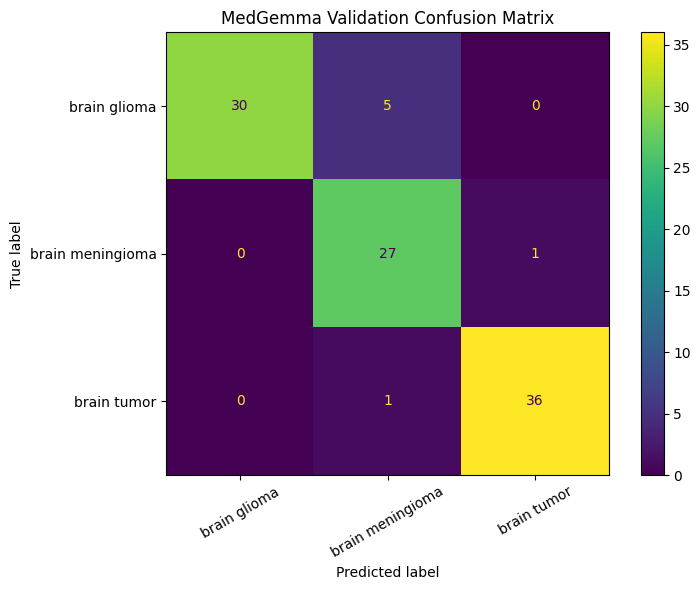

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

matrix = confusion_matrix(
    recognized_results["true_id"],
    recognized_results["predicted_id"],
    labels=[0, 1, 2],
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=LABEL_NAMES,
)

fig, ax = plt.subplots(figsize=(8, 6))
display_matrix.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=30,
)

ax.set_title("MedGemma Validation Confusion Matrix")
plt.tight_layout()
plt.show()

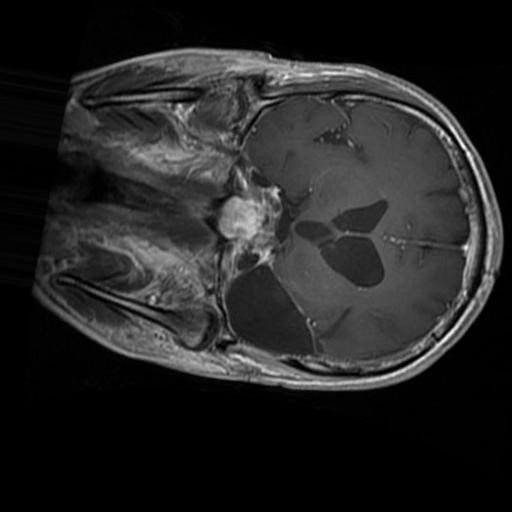

True label: brain glioma
Predicted label: brain meningioma
Raw response: B: brain meningioma


In [ ]:
incorrect = results_df[
    results_df["correct"] == False
]

incorrect[
    [
        "true_label",
        "predicted_label",
        "generated_text",
    ]
].head(20)

incorrect_index = incorrect.index[0]
example = evaluation_subset[int(incorrect_index)]

display(example["image"])
print("True label:", results_df.loc[incorrect_index, "true_label"])
print(
    "Predicted label:",
    results_df.loc[incorrect_index, "predicted_label"],
)
print(
    "Raw response:",
    results_df.loc[incorrect_index, "generated_text"],
)